# Handwritten Digit Recognition using CNN

## Problem Statement

Handwritten digit recognition is a fundamental problem in computer vision and pattern recognition.

The goal of this project is to build a Deep Learning model that can accurately recognize digits (0–9) from grayscale images.

This has real-world applications in:
- Postal code recognition
- Bank cheque processing
- Digitized forms

---

## Objective

- To build a CNN model for digit classification  
- To achieve high accuracy on image data  
- To automate handwritten digit recognition  

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Approach & Methodology

The project follows a structured deep learning workflow:

### Step 1: Data Loading
Load image dataset containing handwritten digits.

### Step 2: Data Preprocessing
Normalize and reshape images for CNN input.

### Step 3: Model Building
Design a Convolutional Neural Network.

### Step 4: Model Training
Train the model using labeled data.

### Step 5: Evaluation
Evaluate model performance using test data.

### Step 6: Prediction
Use trained model to predict new digits.

This pipeline ensures systematic development from raw data to prediction.

In [4]:
train = pd.read_csv('/kaggle/input/datasets/bhavikjikadara/handwritten-digit-recognition/train.csv')

In [5]:
X = train.drop('label', axis=1).values
y = train['label'].values

In [6]:
X = X / 255.0

In [7]:
X = X.reshape(-1, 28, 28, 1)

In [8]:
y = to_categorical(y, 10)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [10]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

##  Understanding the Dataset

The dataset consists of grayscale images of handwritten digits (0–9).

### Key Features:
- Image size: 28 × 28 pixels  
- Grayscale images  
- 10 classes (digits 0–9)

### Observations:
- Images are already centered  
- Low resolution but sufficient for classification  

Understanding the dataset helps in designing the model correctly.

In [11]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-18 08:03:29.214203: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Data Preprocessing

Before feeding data into the model, preprocessing is required:

### Normalization
Pixel values are scaled from [0, 255] to [0, 1]

This improves:
- Training stability  
- Convergence speed  

### Reshaping

CNN expects input in the format:

(samples, height, width, channels)

So we reshape the data to include channel dimension.

## Reshaping Input Data

The dataset originally has shape:

(number_of_samples, 28, 28)

We reshape it into:

(number_of_samples, 28, 28, 1)

###  Why?

- CNN requires channel dimension  
- Grayscale image → 1 channel  

This makes the data compatible with Conv2D layers.

##  CNN Model Architecture

A Convolutional Neural Network is used for feature extraction and classification.

---

### Architecture Components:

#### 1. Convolution Layers
- Extract spatial features  
- Detect edges and patterns  

#### 2. Batch Normalization
- Stabilizes learning  
- Speeds up training  

#### 3. MaxPooling
- Reduces image size  
- Keeps important features  

#### 4. Dropout
- Prevents overfitting  

#### 5. Flatten Layer
- Converts feature maps into vector  

#### 6. Dense Layers
- Perform classification  

#### 7. Softmax Output Layer
- Outputs probabilities for 10 classes  

---

###  Why CNN?

CNN automatically learns features, making it ideal for image-based tasks.

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Compiling the Model

The model is compiled using:

- Optimizer: Adam  
- Loss Function: Categorical Crossentropy  
- Metrics: Accuracy  

This defines how the model learns and evaluates performance.

In [13]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=15
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


591/591 ━━━━━━━━━━━━━━━━━━━━ 61s 96ms/step - accuracy: 0.7191 - loss: 0.9283 - val_accuracy: 0.9848 - val_loss: 0.0576
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 94ms/step - accuracy: 0.9474 - loss: 0.1707 - val_accuracy: 0.9860 - val_loss: 0.0386
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 93ms/step - accuracy: 0.9644 - loss: 0.1145 - val_accuracy: 0.9895 - val_loss: 0.0326
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 56s 94ms/step - accuracy: 0.9716 - loss: 0.0982 - val_accuracy: 0.9855 - val_loss: 0.0375
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 93ms/step - accuracy: 0.9733 - loss: 0.0868 - val_accuracy: 0.9902 - val_loss: 0.0288
Epoch 6/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 93ms/step - accuracy: 0.9775 - loss: 0.0729 - val_accuracy: 0.9921 - val_loss: 0.0221
Epoch 7/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 55s 92ms/step - accuracy: 0.9802 - loss: 0.0662 - val_accuracy: 0.9926 - val_loss: 0.0214
Epoch 8/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 56s 94ms/step - accuracy: 0.9799 - loss: 0.0667 - val_accurac

## Training the Model

The model is trained on the dataset using multiple epochs.

### Key Concepts:

- **Epochs** → Full passes over dataset  
- **Batch Size** → Samples processed per step  

### Goal:
- Reduce loss  
- Increase accuracy  

Validation data helps monitor performance on unseen data.

In [14]:
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9909 - loss: 0.0243
Validation Accuracy: 0.9907143115997314


In [15]:
import matplotlib.pyplot as plt

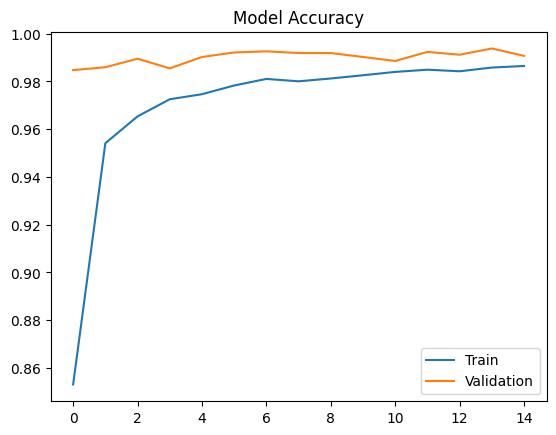

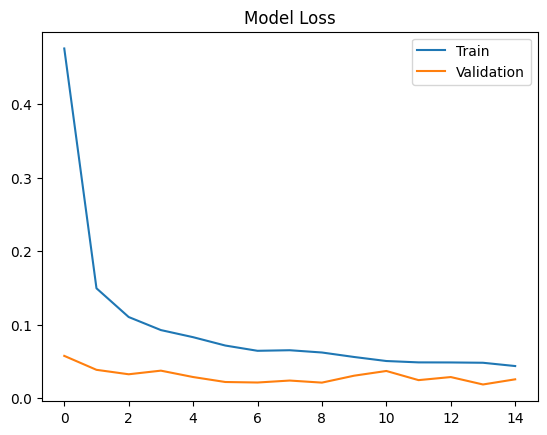

In [16]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:

The trained model is evaluated on test data.

###  Metrics:
- Accuracy  
- Loss  

This step ensures that the model generalizes well and is not overfitting.

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


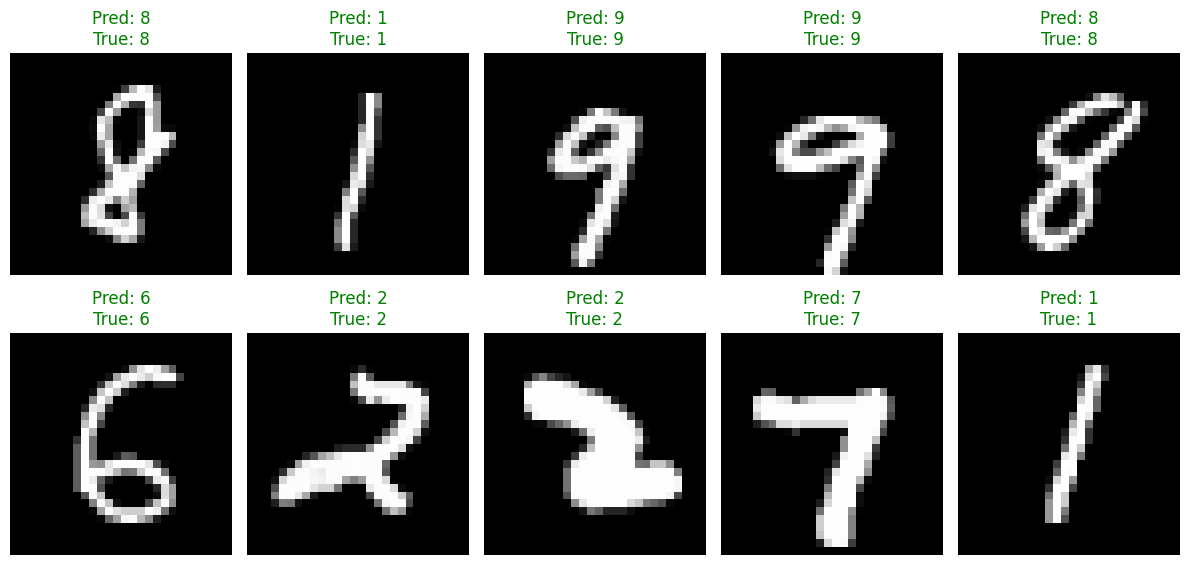

In [17]:

y_pred = model.predict(X_val)


y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)


plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    
    img = X_val[i].reshape(28,28)
    plt.imshow(img, cmap='gray')
    
    pred = y_pred_classes[i]
    true = y_true[i]
    
    color = 'green' if pred == true else 'red'
    
    plt.title(f"Pred: {pred}\nTrue: {true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Making Predictions

The trained model predicts handwritten digits.

### Steps:
1. Input image  
2. Preprocess image  
3. Model prediction  
4. Output digit  

### Output:
- Predicted digit (0–9)  

This demonstrates real-world usability of the model.